In [15]:
from utils.clustering_utils.clustering_preprocessing_utils import ClusteringPreprocessor
preprocessor = ClusteringPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")

In [16]:
sensor_df, target_df = preprocessor.read_data()
preprocessor.feature_selection()
preprocessor.normalize_column(column_name="Angle[degree]ORDistance[mm]")

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.362927,0.568424,0.372094,0.600424
1,2,0.020408,0.323364,0.834875,0.122347,0.877489
2,2,0.040816,0.305129,0.616499,0.310047,0.650414
3,2,0.061224,0.301217,0.368463,0.528873,0.392498
4,2,0.081633,0.286553,0.407888,0.488967,0.433493
...,...,...,...,...,...,...
4995,314,0.918367,0.436014,0.658649,0.316483,0.626846
4996,314,0.938776,0.428604,0.660641,0.312257,0.628918
4997,314,0.959184,0.418442,0.661195,0.308382,0.629494
4998,314,0.979592,0.422698,0.663037,0.308176,0.631409


In [17]:
X = preprocessor.group_and_pad(preprocessor.sensor_df, group_col="Experiment_ID")[:,:,:]
Y = preprocessor.group_and_pad(preprocessor.target_df, group_col="Experiment_ID")[:,:,1:-1]
X.shape, Y.shape

((100, 1743, 16), (100, 50, 3))

In [18]:
from utils.clustering_utils.clustering_alg_utils import KMeansClusterer, KSelectionEvaluator

In [19]:
experiment_ids = list(sensor_df.Experiment_ID.unique().astype(int))
experiment_ids = [int(x) for x in experiment_ids]
experiment_ids

[2,
 4,
 6,
 8,
 10,
 12,
 14,
 16,
 18,
 20,
 22,
 24,
 26,
 28,
 30,
 32,
 34,
 36,
 38,
 39,
 40,
 41,
 42,
 49,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 119,
 124,
 190,
 193,
 196,
 199,
 202,
 205,
 208,
 211,
 214,
 217,
 220,
 223,
 226,
 229,
 232,
 235,
 238,
 241,
 244,
 245,
 246,
 253,
 254,
 255,
 262,
 265,
 268,
 271,
 274,
 277,
 280,
 285,
 290,
 293,
 296,
 299,
 302,
 305,
 308,
 311,
 314]

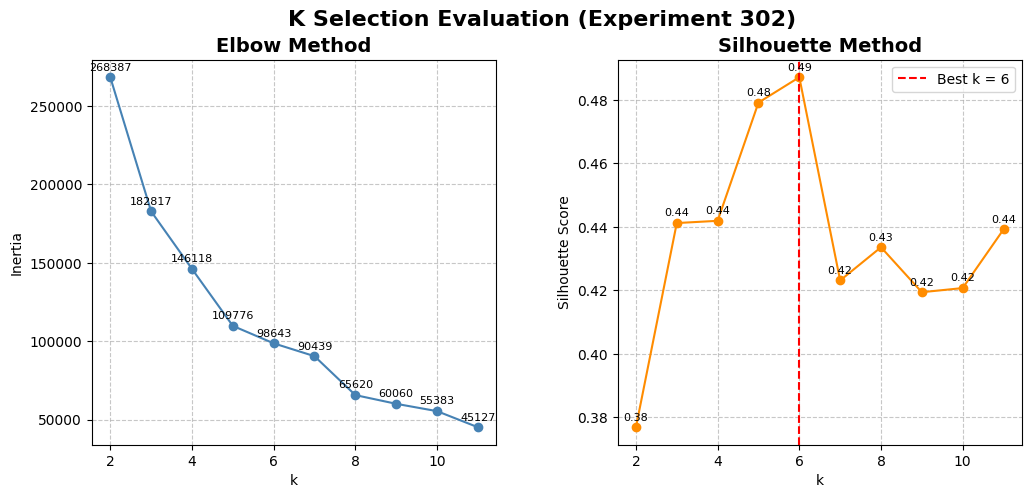

In [20]:
k_selection = KSelectionEvaluator(X, random_state=42, experiment_ids=experiment_ids)
inertias, silhouettes, best_k = k_selection.evaluate(experiment_id=302, window_size=15)

In [21]:
feature_names= list(sensor_df.columns)
feature_names.remove("Experiment_ID")

# "kmeans", "agglo", "dbscan", "kshape", "tskm"

In [22]:
experiment_ids

[2,
 4,
 6,
 8,
 10,
 12,
 14,
 16,
 18,
 20,
 22,
 24,
 26,
 28,
 30,
 32,
 34,
 36,
 38,
 39,
 40,
 41,
 42,
 49,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 119,
 124,
 190,
 193,
 196,
 199,
 202,
 205,
 208,
 211,
 214,
 217,
 220,
 223,
 226,
 229,
 232,
 235,
 238,
 241,
 244,
 245,
 246,
 253,
 254,
 255,
 262,
 265,
 268,
 271,
 274,
 277,
 280,
 285,
 290,
 293,
 296,
 299,
 302,
 305,
 308,
 311,
 314]

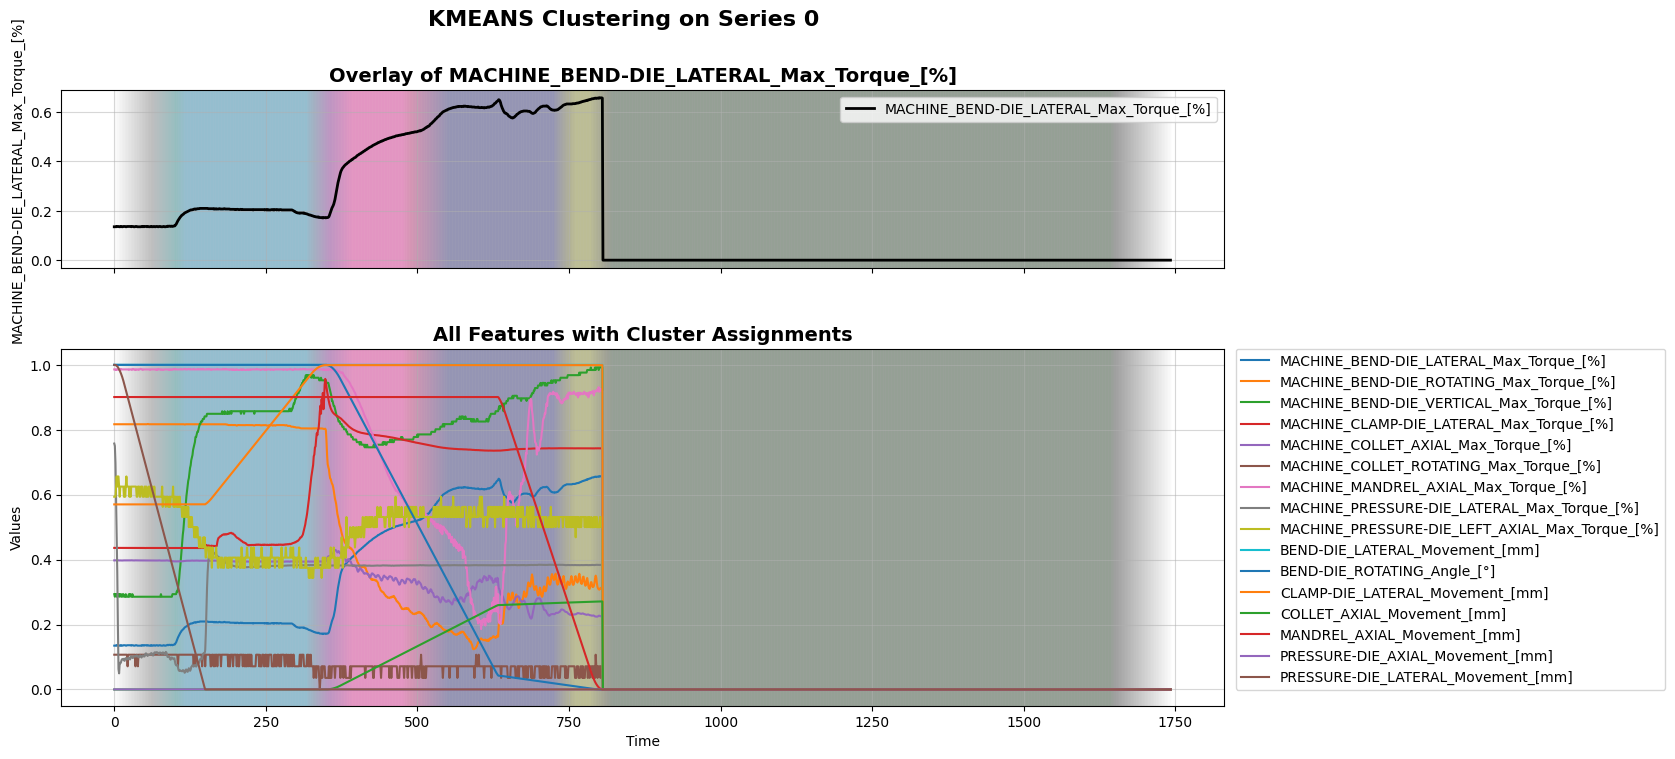

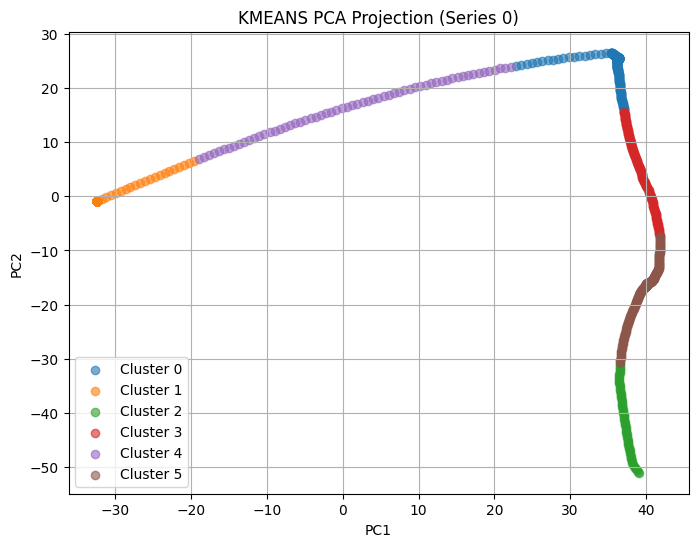

In [23]:
kmeans_clusterer = KMeansClusterer(X, random_state=42, experiment_ids=experiment_ids)
labels, kmeans, subsequences_pca = kmeans_clusterer.cluster(
    experiment_id=2, window_size=100, n_clusters=6,feature_names=feature_names, algorithm= "kmeans"
)

In [24]:
sensor_df[sensor_df["Experiment_ID"]==2]
labels

array([2, 2, 2, ..., 1, 1, 1], shape=(1644,), dtype=int32)

In [25]:
import numpy as np
_, idx = np.unique(labels, return_index=True)
unique_arr = labels[np.sort(idx)]
unique_arr

array([2, 5, 3, 0, 4, 1], dtype=int32)

   start_index  end_index
0           63        163
1           64        164
2           65        165
3           66        166
4           67        167


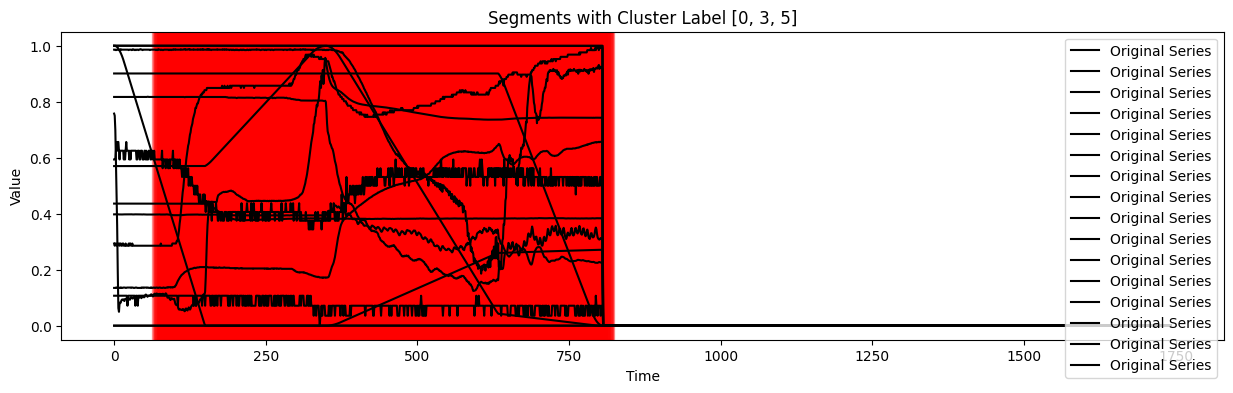

In [26]:
# -----------------------------
# Clustered subsequences example
# -----------------------------
# labels, model, subsequences_pca = clusterer.cluster(
#     experiment_id=2, window_size=10, n_clusters=6, algorithm="kmeans"
# )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

label_of_interest = [0,3,5]
window_size = 100  # same as used in clustering

# -----------------------------
# 1. Get indices of subsequences with the selected label
# -----------------------------
indices_label_1 = np.where(np.isin(labels, label_of_interest))[0]


# -----------------------------
# 2. Extract original subsequences from the series
# -----------------------------
# Map experiment_id to series index
series_idx = kmeans_clusterer.experiment_ids.index(2)
series = kmeans_clusterer.data[series_idx]

# Extract original subsequences
subsequences_label_1 = [series[start : start + window_size] for start in indices_label_1]
subsequences_label_1 = np.array(subsequences_label_1)

# -----------------------------
# 3. Create a DataFrame of timestamps
# -----------------------------
df_label_1_timestamps = pd.DataFrame({
    'start_index': indices_label_1,
    'end_index': indices_label_1 + window_size
})

print(df_label_1_timestamps.head())

# -----------------------------
# 4. Optional: Visualize the segments on the original series
# -----------------------------
plt.figure(figsize=(15, 4))
plt.plot(series, color="black", label="Original Series")
for start in indices_label_1:
    plt.axvspan(start, start + window_size, color="red", alpha=0.3)
plt.title(f"Segments with Cluster Label {label_of_interest}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


In [27]:
import pandas as pd

# Flatten each subsequence: (100 timesteps, 16 features) → 1600 columns
subsequences_flat = subsequences_label_1.reshape(subsequences_label_1.shape[0], -1)

# Create DataFrame
df_label_1 = pd.DataFrame(subsequences_flat)

# Optional: add start index
df_label_1['start_index'] = indices_label_1

print(df_label_1.shape)  # should be (235, 1601)


(662, 1601)


In [28]:
import pandas as pd

# Create a DataFrame with the start indices of the selected label
df_label_1_timestamps = pd.DataFrame({
    'start_index': indices_label_1,
    'end_index': indices_label_1 + window_size  # optional, gives the end of each subsequence
})
start_idx = df_label_1_timestamps.start_index.min()
end_idx = df_label_1_timestamps.end_index.max()
sensor_df[sensor_df["Experiment_ID"]==2].iloc[start_idx: end_idx].nunique()


Experiment_ID                                       1
MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]           247
MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]          541
MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]           61
MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]          358
MACHINE_COLLET_AXIAL_Max_Torque_[%]               665
MACHINE_COLLET_ROTATING_Max_Torque_[%]              4
MACHINE_MANDREL_AXIAL_Max_Torque_[%]              274
MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%]       626
MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%]     10
BEND-DIE_LATERAL_Movement_[mm]                      7
BEND-DIE_ROTATING_Angle_[°]                       458
CLAMP-DIE_LATERAL_Movement_[mm]                   213
COLLET_AXIAL_Movement_[mm]                        461
MANDREL_AXIAL_Movement_[mm]                       179
PRESSURE-DIE_AXIAL_Movement_[mm]                   32
PRESSURE-DIE_LATERAL_Movement_[mm]                 99
dtype: int64